# **0.** Setup

In [ ]:
!pip install pandasql

In [ ]:
# import packages
import pandas as pd
import pandasql as ps #SQL on Pandas Dataframe

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
%%capture
!apt update
!pip install kaggle

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# **1.** Datasets

### **1.1** Kaggle Book Dataset

#### **1.1.0**  Download Dataset

In [ ]:
# Download dataset and read
# https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset?select=Books.csv

!!kaggle datasets download -d arashnic/book-recommendation-dataset --force

!unzip /content/book-recommendation-dataset.zip




Archive:  /content/book-recommendation-dataset.zip
  inflating: Books.csv               
  inflating: DeepRec.png             
  inflating: Ratings.csv             
  inflating: Users.csv               
  inflating: classicRec.png          
  inflating: recsys_taxonomy2.png    


In [ ]:
df_book = pd.read_csv('Books.csv', low_memory=False)
df_rating = pd.read_csv('Ratings.csv')
df_user = pd.read_csv('Users.csv')

#### **1.1.1**  Data Cleaning and Analysis - Books

In [ ]:
# convert dtypes
df_book['Year-Of-Publication'] = pd.to_numeric(df_book['Year-Of-Publication'], errors='coerce')
df_book['Year-Of-Publication'] = df_book['Year-Of-Publication'].astype('Int64')
df_book = df_book.astype({
    'ISBN': 'string',
    'Book-Title': 'string',
    'Book-Author': 'string',
    'Publisher': 'string',
    'Image-URL-S': 'string',
    'Image-URL-M': 'string',
    'Image-URL-L': 'string'
})

# dataset schema
df_book.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  string
 1   Book-Title           271360 non-null  string
 2   Book-Author          271358 non-null  string
 3   Year-Of-Publication  271357 non-null  Int64 
 4   Publisher            271358 non-null  string
 5   Image-URL-S          271360 non-null  string
 6   Image-URL-M          271360 non-null  string
 7   Image-URL-L          271357 non-null  string
dtypes: Int64(1), string(7)
memory usage: 16.8 MB


In [ ]:
df_book['Year-Of-Publication'].describe()

,Year-Of-Publication
count,271357.00
mean,1959.76
std,257.99
min,0.00
25%,1989.00
50%,1995.00
75%,2000.00
max,2050.00


#### **1.1.2**  SQL Queries - Books

In [ ]:
query_book_count_by_year = """
        SELECT "Year-Of-Publication", COUNT(*) as count
        FROM df_book
        GROUP BY "Year-Of-Publication"
        ORDER BY count DESC
        """
result_book_count_by_year = ps.sqldf(query_book_count_by_year, locals())
result_book_count_by_year

,Year-Of-Publication,count
0,2002.00,17627
1,1999.00,17431
2,2001.00,17359
3,2000.00,17232
4,1998.00,15766
...,...,...
112,1904.00,1
113,1897.00,1
114,1806.00,1
115,1378.00,1


In [ ]:
query_book_count_by_author = """
        SELECT "Book-Author", COUNT(*) as count
        FROM df_book
        GROUP BY "Book-Author"
        ORDER BY count DESC
        """
result_book_count_by_author = ps.sqldf(query_book_count_by_author, locals())
result_book_count_by_author

,Book-Author,count
0,Agatha Christie,632
1,William Shakespeare,567
2,Stephen King,524
3,Ann M. Martin,423
4,Carolyn Keene,373
...,...,...
102018,142 moms from all over the world,1
102019,'N Sync,1
102020,Mimma Balia,1
102021,J. D. Landis,1


In [ ]:
df_book

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


#### **1.2.1**  Data Cleaning and Analysis - Ratings

In [ ]:
df_rating = df_rating.astype({'ISBN': 'string'})
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  string
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), string(1)
memory usage: 26.3 MB


In [ ]:
df_rating['Book-Rating'].describe()

,Book-Rating
count,1149780.00
mean,2.87
std,3.85
min,0.00
25%,0.00
50%,0.00
75%,7.00
max,10.00


#### **1.2.2**  SQL Queries - Books

In [ ]:
query_rating_count_avg_by_isbn = """
        SELECT ISBN,
              COUNT(*) as rating_count,
              AVG("Book-Rating") as avg_rating
        FROM df_rating
        GROUP BY ISBN
        ORDER BY rating_count DESC
        """
result_rating_count_avg_by_isbn = ps.sqldf(query_rating_count_avg_by_isbn, locals())
result_rating_count_avg_by_isbn

,ISBN,rating_count,avg_rating
0,0971880107,2502,1.02
1,0316666343,1295,4.47
2,0385504209,883,4.65
3,0060928336,732,3.45
4,0312195516,723,4.33
...,...,...,...
340551,9044922718,1,0.00
340552,9044922572,1,0.00
340553,9044922564,1,0.00
340554,9032803328,1,0.00


In [ ]:
df_rating

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [ ]:
query_rating_stat_join_book = """
        WITH rating_stats AS (
            SELECT ISBN,
                   COUNT(*) as rating_count,
                   AVG("Book-Rating") as avg_rating
            FROM df_rating
            GROUP BY ISBN
        )
        SELECT *
        FROM rating_stats r
        JOIN df_book b
        ON r.ISBN = b.ISBN
        ORDER BY r.rating_count DESC
        """
result_rating_stat_join_book = ps.sqldf(query_rating_stat_join_book, locals())
result_rating_stat_join_book

,ISBN,rating_count,avg_rating,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0971880107,2502,1.02,0971880107,Wild Animus,Rich Shapero,2004.00,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
1,0316666343,1295,4.47,0316666343,The Lovely Bones: A Novel,Alice Sebold,2002.00,"Little, Brown",http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...
2,0385504209,883,4.65,0385504209,The Da Vinci Code,Dan Brown,2003.00,Doubleday,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...
3,0060928336,732,3.45,0060928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997.00,Perennial,http://images.amazon.com/images/P/0060928336.0...,http://images.amazon.com/images/P/0060928336.0...,http://images.amazon.com/images/P/0060928336.0...
4,0312195516,723,4.33,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant,1998.00,Picador USA,http://images.amazon.com/images/P/0312195516.0...,http://images.amazon.com/images/P/0312195516.0...,http://images.amazon.com/images/P/0312195516.0...
...,...,...,...,...,...,...,...,...,...,...,...
270146,0440400988,1,7.00,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988.00,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
270147,0525447644,1,4.00,0525447644,From One to One Hundred,Teri Sloat,1991.00,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
270148,006008667X,1,0.00,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004.00,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
270149,0192126040,1,0.00,0192126040,Republic (World's Classics),Plato,1996.00,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


### **1.2** Amazon-popular-books-dataset

In [ ]:
df_book_az = pd.read_csv('Amazon_popular_books_dataset.csv')

In [ ]:
# dataset schema
df_book_az.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2269 entries, 0 to 2268
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   asin                  2269 non-null   object 
 1   ISBN10                1429 non-null   object 
 2   answered_questions    2269 non-null   int64  
 3   availability          1375 non-null   object 
 4   brand                 2268 non-null   object 
 5   currency              2269 non-null   object 
 6   date_first_available  3 non-null      object 
 7   delivery              2269 non-null   object 
 8   department            0 non-null      float64
 9   description           712 non-null    object 
 10  discount              1177 non-null   float64
 11  domain                2269 non-null   object 
 12  features              2269 non-null   object 
 13  final_price           1392 non-null   float64
 14  format                2173 non-null   object 
 15  image_url            

In [ ]:
df_book_az

,asin,ISBN10,answered_questions,availability,brand,currency,date_first_available,delivery,department,description,...,upc,url,video,video_count,categories,best_sellers_rank,buybox_seller,image,number_of_sellers,colors
0,0007350813,0007350813,0,In Stock.,Emily Brontë,USD,NaN,"[""FREE delivery Tuesday, December 28 if you sp...",NaN,NaN,...,NaN,https://www.amazon.com/dp/0007350813,NaN,0,"[""Books"",""Literature & Fiction"",""Genre Fiction""]","[{""category"":""Books / Literature & Fiction / H...",NaN,NaN,NaN,NaN
1,0007513763,9780007513765,0,In Stock.,Drew Daywalt,USD,NaN,"[""FREE delivery Tuesday, December 28 if you sp...",NaN,NaN,...,NaN,https://www.amazon.com/dp/0007513763,NaN,0,"[""Books"",""Children's Books"",""Literature & Fict...","[{""category"":""Books / Children's Books / Liter...",VMG Books & Media,NaN,NaN,NaN
2,0008183988,0008183988,0,NaN,Bernard Cornwell,USD,NaN,"[""FREE delivery January 4 - 10 if you spend $2...",NaN,NaN,...,NaN,https://www.amazon.com/dp/0008183988,NaN,0,"[""Books"",""Literature & Fiction"",""Genre Fiction""]","[{""category"":""Books / Literature & Fiction / H...",Reuseaworld,NaN,NaN,NaN
3,0008305838,0008305838,0,In Stock.,David Walliams,USD,NaN,"[""FREE delivery Tuesday, December 28 if you sp...",NaN,NaN,...,NaN,https://www.amazon.com/dp/0008305838,NaN,0,"[""Books"",""Children's Books"",""Literature & Fict...","[{""category"":""Books / Children's Books / Liter...",Bahamut Media,NaN,NaN,NaN
4,0008375526,0008375526,0,In Stock.,Caroline Hirons,USD,NaN,"[""FREE delivery Tuesday, December 28"",""Or fast...",NaN,NaN,...,NaN,https://www.amazon.com/dp/0008375526,NaN,0,"[""Books"",""Crafts, Hobbies & Home"",""Home Improv...","[{""category"":""Books / Health, Fitness & Dietin...",KathrynAshleyGallery,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,B07P5BPVGM,NaN,0,NaN,Jess Lourey,USD,NaN,[],NaN,NaN,...,NaN,https://www.amazon.com/dp/B07P5BPVGM,NaN,0,"[""Books"",""Mystery, Thriller & Suspense"",""Thril...","[{""category"":""Books / Mystery, Thriller & Susp...",NaN,NaN,NaN,NaN
2265,B07P5JBCFL,NaN,0,NaN,"Heidi Murkoff (Author, Narrator), Meeghan Hola...",USD,NaN,[],NaN,NaN,...,NaN,https://www.amazon.com/dp/B07P5JBCFL,NaN,0,"[""Books"",""Health, Fitness & Dieting"",""Women's ...","[{""category"":""Books / Health, Fitness & Dietin...",NaN,NaN,NaN,NaN
2266,B07NF7DFS2,NaN,0,NaN,"Clea Shearer (Author, Narrator), Joanna Teplin...",USD,NaN,[],NaN,NaN,...,NaN,https://www.amazon.com/dp/B07NF7DFS2,NaN,0,"[""Books"",""Crafts, Hobbies & Home"",""Home Improv...","[{""category"":""Audible Books & Originals / Home...",NaN,NaN,NaN,NaN
2267,B07P67N918,NaN,0,NaN,"Lisa Jewell (Author), Tamaryn Payne (Narrator)...",USD,NaN,[],NaN,NaN,...,NaN,https://www.amazon.com/dp/B07P67N918,NaN,0,"[""Books"",""Mystery, Thriller & Suspense"",""Thril...","[{""category"":""Audible Books & Originals / Myst...",NaN,NaN,NaN,NaN


### **1.3** Amazon Kindle Books Dataset 2023

In [ ]:
# Download dataset and read
# https://www.kaggle.com/datasets/asaniczka/amazon-kindle-books-dataset-2023-130k-books

!!kaggle datasets download -d asaniczka/amazon-kindle-books-dataset-2023-130k-books --force

!unzip /content/amazon-kindle-books-dataset-2023-130k-books.zip

Archive:  /content/amazon-kindle-books-dataset-2023-130k-books.zip
  inflating: kindle_data-v2.csv      


In [ ]:
df_book_kd = pd.read_csv('kindle_data-v2.csv')

In [ ]:
df_book_kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133102 entries, 0 to 133101
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   asin               133102 non-null  object 
 1   title              133102 non-null  object 
 2   author             132677 non-null  object 
 3   soldBy             123869 non-null  object 
 4   imgUrl             133102 non-null  object 
 5   productURL         133102 non-null  object 
 6   stars              133102 non-null  float64
 7   reviews            133102 non-null  int64  
 8   price              133102 non-null  float64
 9   isKindleUnlimited  133102 non-null  bool   
 10  category_id        133102 non-null  int64  
 11  isBestSeller       133102 non-null  bool   
 12  isEditorsPick      133102 non-null  bool   
 13  isGoodReadsChoice  133102 non-null  bool   
 14  publishedDate      84086 non-null   object 
 15  category_name      133102 non-null  object 
dtypes:

In [ ]:
df_book_kd

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
0,B00TZE87S4,Adult Children of Emotionally Immature Parents...,Lindsay C. Gibson,Amazon.com Services LLC,https://m.media-amazon.com/images/I/713KZTsaYp...,https://www.amazon.com/dp/B00TZE87S4,4.80,0,9.99,False,6,True,False,False,2015-06-01,Parenting & Relationships
1,B08WCKY8MB,"From Strength to Strength: Finding Success, Ha...",Arthur C. Brooks,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/A1LZcJFs9E...,https://www.amazon.com/dp/B08WCKY8MB,4.40,0,16.99,False,6,False,False,False,2022-02-15,Parenting & Relationships
2,B09KPS84CJ,Good Inside: A Guide to Becoming the Parent Yo...,Becky Kennedy,HarperCollins Publishers,https://m.media-amazon.com/images/I/71RIWM0sv6...,https://www.amazon.com/dp/B09KPS84CJ,4.80,0,16.99,False,6,False,True,False,2022-09-13,Parenting & Relationships
3,B07S7QPG6J,Everything I Know About Love: A Memoir,Dolly Alderton,HarperCollins Publishers,https://m.media-amazon.com/images/I/71QdQpTiKZ...,https://www.amazon.com/dp/B07S7QPG6J,4.20,0,9.95,True,6,False,True,False,2020-02-25,Parenting & Relationships
4,B00N6PEQV0,The Seven Principles for Making Marriage Work:...,John Gottman,Random House LLC,https://m.media-amazon.com/images/I/813o4WOs+w...,https://www.amazon.com/dp/B00N6PEQV0,4.70,0,13.99,False,6,False,False,False,2015-05-05,Parenting & Relationships
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133097,B0C3SJDLK8,Anna Karenina,Leo Tolstoy,De Marque,https://m.media-amazon.com/images/I/61RXEyMctk...,https://www.amazon.com/dp/B0C3SJDLK8,4.70,0,0.00,False,29,True,False,False,2023-09-15,Nonfiction
133098,B09DW752Y1,Scary Smart: Scary Smart: The Future of Artifi...,Mo Gawdat,Amazon.com Services LLC,https://m.media-amazon.com/images/I/71tjf6R-Wa...,https://www.amazon.com/dp/B09DW752Y1,4.40,0,9.99,False,29,False,False,False,2021-09-30,Nonfiction
133099,B0CFWHPJTN,The Count of Monte Cristo: The Original Unabri...,Alexandre Dumas,De Marque,https://m.media-amazon.com/images/I/71zcCb5Pvu...,https://www.amazon.com/dp/B0CFWHPJTN,4.80,0,1.99,False,29,True,False,False,2023-09-15,Nonfiction
133100,B0C1KMFXJC,War And Peace,Leo Tolstoy,De Marque,https://m.media-amazon.com/images/I/715QpZlzmi...,https://www.amazon.com/dp/B0C1KMFXJC,4.70,0,0.00,False,29,True,False,False,2023-08-25,Nonfiction


In [ ]:
query = """
        SELECT k.*, b.*
        FROM df_book_kd k
        INNER JOIN df_book b
        ON k.asin = b.ISBN
        """


df_book_joined = ps.sqldf(query, locals())


df_book_joined

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,...,publishedDate,category_name,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0440414806,Holes (Holes Series),Louis Sachar,None,https://m.media-amazon.com/images/I/81Sa-V91DC...,https://www.amazon.com/dp/0440414806,4.70,0,4.94,0,...,2000-05-09,Children's eBooks,0440414806,Holes (Yearling Newbery),LOUIS SACHAR,2000,Yearling,http://images.amazon.com/images/P/0440414806.0...,http://images.amazon.com/images/P/0440414806.0...,http://images.amazon.com/images/P/0440414806.0...
1,0064400557,Charlotte's Web: A Newbery Honor Award Winner ...,E. B. White,None,https://m.media-amazon.com/images/I/917FQerThO...,https://www.amazon.com/dp/0064400557,4.80,0,6.39,0,...,2012-04-10,Children's eBooks,0064400557,Charlotte's Web (Trophy Newbery),E. B. White,1974,HarperTrophy,http://images.amazon.com/images/P/0064400557.0...,http://images.amazon.com/images/P/0064400557.0...,http://images.amazon.com/images/P/0064400557.0...
2,0380807343,Coraline,Neil Gaiman,None,https://m.media-amazon.com/images/I/71FvtJvTkR...,https://www.amazon.com/dp/0380807343,4.70,0,7.97,0,...,2012-04-24,Children's eBooks,0380807343,Coraline,Neil Gaiman,2003,HarperTrophy,http://images.amazon.com/images/P/0380807343.0...,http://images.amazon.com/images/P/0380807343.0...,http://images.amazon.com/images/P/0380807343.0...
3,0064471047,"The Lion, the Witch, and the Wardrobe",C. S. Lewis,None,https://m.media-amazon.com/images/I/813bGDo5dk...,https://www.amazon.com/dp/0064471047,4.70,0,7.64,0,...,2002-03-05,Children's eBooks,0064471047,"The Lion, the Witch, and the Wardrobe (The Chr...",C. S. Lewis,1994,HarperCollins,http://images.amazon.com/images/P/0064471047.0...,http://images.amazon.com/images/P/0064471047.0...,http://images.amazon.com/images/P/0064471047.0...
4,0440412676,Where the Red Fern Grows,Wilson Rawls,None,https://m.media-amazon.com/images/I/9107nnFtIW...,https://www.amazon.com/dp/0440412676,4.80,0,8.99,0,...,1996-09-01,Children's eBooks,0440412676,Where the Red Fern Grows: The Story of Two Dog...,Wilson Rawls,1996,Yearling Books,http://images.amazon.com/images/P/0440412676.0...,http://images.amazon.com/images/P/0440412676.0...,http://images.amazon.com/images/P/0440412676.0...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,0394800877,Yertle the Turtle and Other Stories,Dr. Seuss,None,https://m.media-amazon.com/images/I/81SuDO-0XI...,https://www.amazon.com/dp/0394800877,4.90,0,10.96,0,...,1958-04-12,Children's eBooks,0394800877,Yertle the Turtle,Dr Seuss,1958,Random House Children's Books,http://images.amazon.com/images/P/0394800877.0...,http://images.amazon.com/images/P/0394800877.0...,http://images.amazon.com/images/P/0394800877.0...
276,0486264726,The Call of the Wild,Jack London,None,https://m.media-amazon.com/images/I/61EWclqmmf...,https://www.amazon.com/dp/0486264726,4.40,0,3.00,0,...,1990-07-01,Children's eBooks,0486264726,The Call of the Wild (Dover Thrift Editions),Jack London,1990,Dover Publications,http://images.amazon.com/images/P/0486264726.0...,http://images.amazon.com/images/P/0486264726.0...,http://images.amazon.com/images/P/0486264726.0...
277,0590466186,"The Girl Who Cried Monster (Goosebumps, No. 8)",R. L. Stine,None,https://m.media-amazon.com/images/I/91Txc-UuNs...,https://www.amazon.com/dp/0590466186,4.40,0,1.99,0,...,1993-05-01,Children's eBooks,0590466186,"The Girl Who Cried Monster (Goosebumps, No 8)",R. L. Stine,1995,Scholastic,http://images.amazon.com/images/P/0590466186.0...,http://images.amazon.com/images/P/0590466186.0...,http://images.amazon.com/images/P/0590466186.0...
278,0679892648,Sammy Keyes and the Hotel Thief,Wendelin Van Draanen,None,https://m.media-amazon.com/images/I/81CJwoa1Rl...,https://www.amazon.com/dp/0679892648,4.70,0,7.99,0,...,1998-08-18,Children's eBooks,0679892648,Sammy Keyes and the Hotel Thief,Wendelin Van Draanen,1998,Yearling Books,http://images.am

### **1.4** graph-rec-goodreads Dataset 2017

In [ ]:
import zipfile
# Download dataset and read
# https://www.kaggle.com/datasets/eremeevd/graph-rec-goodreads

!!kaggle datasets download -d eremeevd/graph-rec-goodreads --force

['Dataset URL: https://www.kaggle.com/datasets/eremeevd/graph-rec-goodreads',
 'License(s): other',
 'Downloading graph-rec-goodreads.zip to /content',
 '',
 '  0% 0.00/2.91G [00:00<?, ?B/s]',
 '  0% 1.00M/2.91G [00:00<19:16, 2.70MB/s]',
 '  0% 9.00M/2.91G [00:00<02:15, 22.9MB/s]',
 '  0% 13.0M/2.91G [00:00<02:15, 23.0MB/s]',
 '  1% 17.0M/2.91G [00:00<02:10, 23.8MB/s]',
 '  1% 21.0M/2.91G [00:00<01:59, 25.9MB/s]',
 '  1% 30.0M/2.91G [00:01<01:14, 41.5MB/s]',
 '  1% 35.0M/2.91G [00:01<01:37, 31.6MB/s]',
 '  1% 39.0M/2.91G [00:01<02:12, 23.2MB/s]',
 '  1% 43.0M/2.91G [00:01<02:10, 23.6MB/s]',
 '  2% 53.0M/2.91G [00:01<01:21, 37.7MB/s]',
 '  2% 61.0M/2.91G [00:02<01:17, 39.3MB/s]',
 '  2% 67.0M/2.91G [00:02<01:13, 41.6MB/s]',
 '  2% 72.0M/2.91G [00:02<01:14, 41.1MB/s]',
 '  3% 79.0M/2.91G [00:02<01:29, 33.9MB/s]',
 '  3% 87.0M/2.91G [00:02<01:16, 39.5MB/s]',
 '  3% 101M/2.91G [00:02<00:50, 59.7MB/s] ',
 '  4% 109M/2.91G [00:03<00:49, 60.6MB/s]',
 '  4% 123M/2.91G [00:03<00:45, 65.4MB/s]',

In [ ]:
import zipfile
import time

start_time = time.time()

# filter books with rating_count >= 800
with zipfile.ZipFile('/content/graph-rec-goodreads.zip', 'r') as z:
    with z.open('goodreads-books/goodreads_books.json') as f:
        chunk_size = 50000
        filtered_chunks = []

        for chunk in pd.read_json(f, lines=True, chunksize=chunk_size):
          chunk['ratings_count'] = pd.to_numeric(chunk['ratings_count'], errors='coerce')
          filtered_chunk = chunk[chunk['ratings_count'] >= 800]
          filtered_chunks.append(filtered_chunk)

        df_book_gr = pd.concat(filtered_chunks, ignore_index=True)

end_time = time.time()
print(f"Runtime: {end_time - start_time:.2f} seconds")

KeyboardInterrupt: 

In [ ]:
df_book_gr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109297 entries, 0 to 109296
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   isbn                  109297 non-null  object 
 1   text_reviews_count    109297 non-null  object 
 2   series                109297 non-null  object 
 3   country_code          109297 non-null  object 
 4   language_code         109297 non-null  object 
 5   popular_shelves       109297 non-null  object 
 6   asin                  109297 non-null  object 
 7   is_ebook              109297 non-null  object 
 8   average_rating        109297 non-null  object 
 9   kindle_asin           109297 non-null  object 
 10  similar_books         109297 non-null  object 
 11  description           109297 non-null  object 
 12  format                109297 non-null  object 
 13  link                  109297 non-null  object 
 14  authors               109297 non-null  object 
 15  

In [ ]:
df_book_gr

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,0743294297,3282,[],US,eng,"[{'count': '7615', 'name': 'to-read'}, {'count...",,false,3.49,B002ENBLOK,...,7,,2009,https://www.goodreads.com/book/show/6066819-be...,https://s.gr-assets.com/assets/nophoto/book/11...,6066819,51184.0,6243154,Best Friends Forever,Best Friends Forever
1,0922915113,39,[],US,,"[{'count': '961', 'name': 'to-read'}, {'count'...",,false,3.81,B00AFYVB8Q,...,4,,2000,https://www.goodreads.com/book/show/287149.The...,https://images.gr-assets.com/books/1328768789m...,287149,986.0,278586,The Devil's Notebook,The Devil's Notebook
2,0800759494,2885,[],US,,"[{'count': '9381', 'name': 'to-read'}, {'count...",,false,3.91,B00B853QPM,...,,,,https://www.goodreads.com/book/show/89375.90_M...,https://s.gr-assets.com/assets/nophoto/book/11...,89375,68157.0,2957021,90 Minutes in Heaven: A True Story of Death an...,90 Minutes in Heaven: A True Story of Death an...
3,0842379428,566,[],US,eng,"[{'count': '6393', 'name': 'to-read'}, {'count...",,false,4.26,B000FCKCJC,...,,,,https://www.goodreads.com/book/show/89376.Heaven,https://images.gr-assets.com/books/1406508230m...,89376,7345.0,86257,Heaven,Heaven
4,037583687X,615,[],US,,"[{'count': '4248', 'name': 'to-read'}, {'count...",,false,3.98,B0010SEMV4,...,7,,2006,https://www.goodreads.com/book/show/89377.Penn...,https://images.gr-assets.com/books/1320470906m...,89377,6949.0,86258,Penny from Heaven,Penny from Heaven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109292,1592911196,53,[],US,eng,"[{'count': '625', 'name': 'to-read'}, {'count'...",,false,3.74,B000FC29J8,...,8,,2011,https://www.goodreads.com/book/show/10644600-f...,https://images.gr-assets.com/books/1350850473m...,10644600,853.0,18566693,Fevre Dream,Fevre Dream
109293,,20,[431681],US,eng,"[{'count': '279', 'name': 'to-read'}, {'count'...",B0095IATR2,true,3.90,B0095IATR2,...,10,First,2012,https://www.goodreads.com/book/show/17250782-c...,https://images.gr-assets.com/books/1358212877m...,17250782,889.0,21803401,"City of Screams (The Order of the Sanguines, #...","City of Screams (The Order of the Sanguines, #..."
109294,,7,[],US,en-GB,"[{'count': '3379', 'name': 'to-read'}, {'count...",B005IH0320,true,4.27,,...,10,,2011,https://www.goodreads.com/book/show/13057172-g...,https://s.gr-assets.com/assets/nophoto/book/11...,13057172,839.0,17073902,Gangsta Granny,Gangsta Granny
109295,,55,[],US,,"[{'count': '1684', 'name': 'to-read'}, {'count...",,false,3.78,,...,7,,2007,https://www.goodreads.com/book/show/1885730.Jo...,https://images.gr-assets.com/books/1376736258m...,1885730,1094.0,1886909,Joel and Cat Set the Story Straight,Joel and Cat Set the Story Straight


In [ ]:
# save filtered df as csv
chunk_size = 50000

for i in range(0, len(df_book_gr), chunk_size):
    df_book_gr[i:i+chunk_size].to_csv('/content/drive/My Drive/CIS5500_goodreads_books_reviewcount_800_dataset.csv',
                                      index=False,
                                      mode='a' if i > 0 else 'w',
                                      header=i==0)



### **4.** GoodReads Authors (more attributes)

In [ ]:
# Download dataset and read
# https://www.kaggle.com/datasets/choobani/goodread-authors

!!kaggle datasets download -d choobani/goodread-authors --force

!unzip /content/goodread-authors.zip

Archive:  /content/goodread-authors.zip
replace final_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: final_dataset.csv       


In [ ]:
df_author_full = pd.read_csv('final_dataset.csv')
df_author_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209517 entries, 0 to 209516
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   authorid           209517 non-null  int64  
 1   name               209517 non-null  object 
 2   workcount          209517 non-null  int64  
 3   fan_count          209517 non-null  int64  
 4   gender             209517 non-null  object 
 5   image_url          209517 non-null  object 
 6   about              86724 non-null   object 
 7   born               31230 non-null   object 
 8   died               12488 non-null   object 
 9   influence          7882 non-null    object 
 10  average_rate       209517 non-null  float64
 11  rating_count       209517 non-null  int64  
 12  review_count       209517 non-null  int64  
 13  website            58320 non-null   object 
 14  twitter            35122 non-null   object 
 15  genre              73983 non-null   object 
 16  or

In [ ]:
import pandasql as ps

query = """
        SELECT f.*, s.*,
               CASE WHEN f.name = s.name THEN 1 ELSE 0 END as name_match
        FROM df_author_full f
        INNER JOIN df_author_gr s
        ON f.authorid = s.author_id
        """

df_author_joined = ps.sqldf(query, locals())
df_author_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157999 entries, 0 to 157998
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   authorid            157999 non-null  int64  
 1   name                157999 non-null  object 
 2   workcount           157999 non-null  int64  
 3   fan_count           157999 non-null  int64  
 4   gender              157999 non-null  object 
 5   image_url           157999 non-null  object 
 6   about               79395 non-null   object 
 7   born                29225 non-null   object 
 8   died                11599 non-null   object 
 9   influence           7485 non-null    object 
 10  average_rate        157999 non-null  float64
 11  rating_count        157999 non-null  int64  
 12  review_count        157999 non-null  int64  
 13  website             53951 non-null   object 
 14  twitter             32177 non-null   object 
 15  genre               68103 non-null

In [ ]:
name_match_sum = df_author_joined['name_match'].sum()
name_match_sum

145660

In [ ]:
df_author_joined

,authorid,name,workcount,fan_count,gender,image_url,about,born,died,influence,...,original_hometown,country,latitude,longitude,average_rating,author_id,text_reviews_count,name,ratings_count,name_match
0,8409092,Jason Wallace,2,13,male,https://images.gr-assets.com/authors/148926684...,Jason Wallace is related to Tolkien and a desc...,None,None,None,...,Cheltenham,United Kingdom,51.90,-2.08,3.78,8409092,151,Jason Wallace,826,1
1,8421525,Nanna Foss,6,156,female,https://images.gr-assets.com/authors/140908587...,Danish YA writer. <br /><br />I make up storie...,None,None,None,...,None,None,NaN,NaN,4.45,8421525,95,Nanna Foss,432,1
2,158146,Terri Savelle Foy,23,125,female,https://images.gr-assets.com/authors/147569460...,"For years, Terri Savelle Foy’s life was averag...",None,None,None,...,None,None,NaN,NaN,4.50,158146,42,Terri Savelle Foy,333,1
3,7189636,Shweta Punj,2,3,unknown,https://s.gr-assets.com/assets/nophoto/user/u_...,None,None,None,None,...,None,None,NaN,NaN,3.57,7189636,22,Shweta Punj,178,1
4,7271316,Phil Hamman,6,6,male,https://images.gr-assets.com/authors/144966390...,Phil Hamman is the co-author of the #1 nationa...,1958-03-07,None,None,...,None,None,NaN,NaN,3.76,7271316,106,Phil Hamman,668,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157994,67759,Rosanne Bittner,75,482,female,https://images.gr-assets.com/authors/142798670...,I am a USA-TODAY best-selling authors with 35 ...,None,None,None,...,"LaPorte, Indiana",United States,41.71,-86.90,4.29,67759,912,Rosanne Bittner,8500,1
157995,34924,Richard Bandler,95,242,unknown,https://images.gr-assets.com/authors/141698214...,None,None,None,None,...,None,None,NaN,NaN,4.00,34924,370,Richard Bandler,6430,1
157996,16617,Norman Bodek,20,7,male,https://s.gr-assets.com/assets/nophoto/user/m_...,"They Always Said, “He Will Never, Ever Make it...",None,None,None,...,new york,United States,40.71,-74.01,4.04,16617,44,Norman Bodek,1030,1
157997,295802,Augusto Cury,78,253,unknown,https://images.gr-assets.com/authors/131521861...,"Augusto Jorge Cury (Colina, 2 de outubro de 19...",1958-10-02,None,None,...,Colina,Macao,22.18,113.53,3.80,295802,406,Augusto Cury,6055,1


In [ ]:
df_author_joined.to_csv('/content/authors_joined.csv', index=False)

analysis on author datasets

In [29]:
author_country_df = df_author_joined['country'].value_counts().reset_index(name='count').rename(columns={'index': 'country'})
author_country_df

,country,count
0,United States,18216
1,United Kingdom,4803
2,Canada,1422
3,France,1022
4,Germany,960
...,...,...
210,Guinea-Bissau,1
211,Anguilla,1
212,Lesotho,1
213,Åland,1


from matplotlib import pyplot as plt
author_country_df['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
author_country_df['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

In [30]:
author_gender_df = df_author_joined['gender'].value_counts().reset_index(name='count').rename(columns={'index': 'gender'})
author_gender_df

,gender,count
0,unknown,77526
1,male,41983
2,female,38490


In [43]:
author_year_df = df_author_joined['born'].str[:4].value_counts().reset_index(name='count').rename(columns={'index': 'born'}).sort_values(by='born', ascending=False)

author_year_df

,born,count
284,2012,1
293,2011,1
285,2010,1
299,2009,1
281,2007,1
...,...,...
292,1686,1
229,1685,4
280,1684,1
297,1683,1


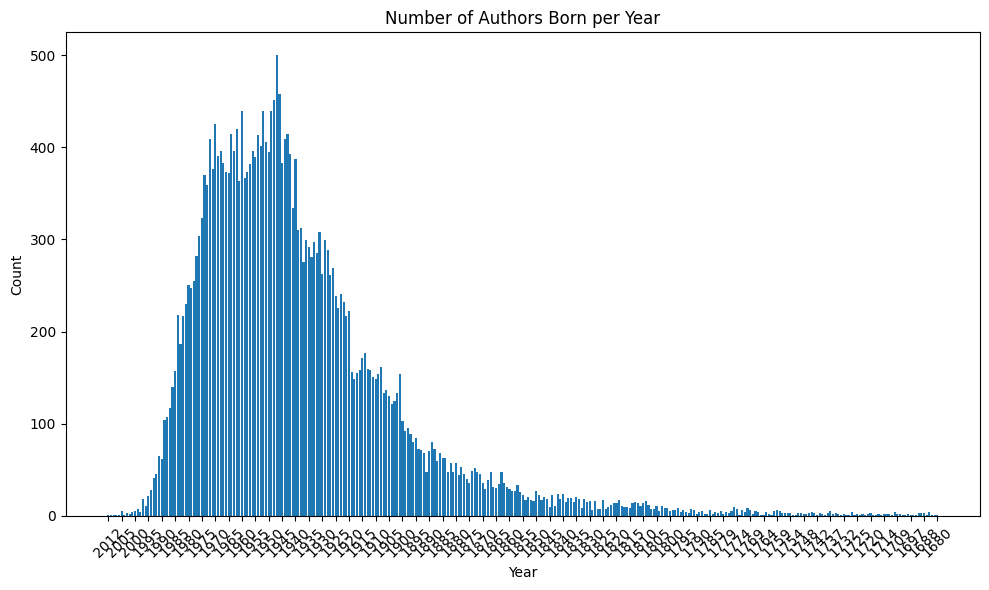

In [44]:
import matplotlib.pyplot as plt

# Creating a bar plot for author_year_df
plt.figure(figsize=(10, 6))
plt.bar(author_year_df['born'], author_year_df['count'])

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number of Authors Born per Year')

# Displaying fewer x-ticks (e.g., every 5 years)
plt.xticks(author_year_df['born'][::5], rotation=45)

# Displaying the plot
plt.tight_layout()
plt.show()


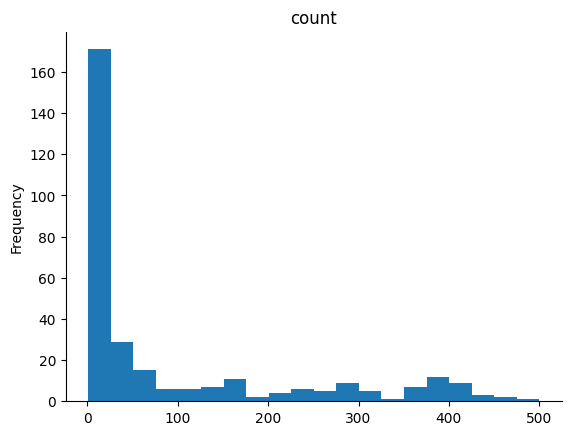

In [38]:
# @title count

from matplotlib import pyplot as plt
author_year_df['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

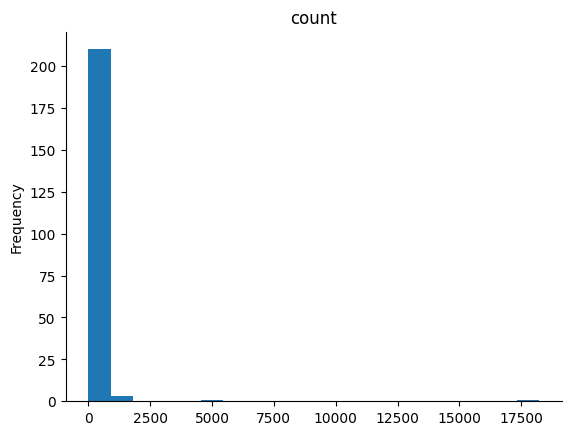

In [28]:
# @title count

from matplotlib import pyplot as plt
author_country_df['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

### test

In [ ]:
# Download dataset
!!kaggle datasets download -d michaelrussell4/10000-books-and-their-genres-standardized

# Unzip folder in Colab content folder
!unzip /content/10000-books-and-their-genres-standardized.zip

Archive:  /content/10000-books-and-their-genres-standardized.zip
  inflating: books_and_genres.csv    


In [ ]:
# read
df = pd.read_csv('books_and_genres.csv')

# Display the first few rows of the DataFrame
df

,Unnamed: 0,title,text,genres
0,0,apocolocyntosis,"Produced by Ted Garvin, Ben Courtney and PG Di...","{'21st-century', 'history', 'roman', 'classics..."
1,1,the house on the borderland,"Produced by Suzanne Shell, Sjaani and PG Distr...","{'horror', 'mystery', 'classics', 'science-fic..."
2,2,the warriors,"Produced by Charles Aldarondo, Charlie Kirschn...","{'literary-fiction', 'history', 'biography', '..."
3,3,a voyage to the moon,"Produced by Christine De Ryck, Stig M. Valstad...","{'20th-century', 'science-fiction', 'speculati..."
4,4,la fiammetta,"Produced by Ted Garvin, Dave Morgan and PG Dis...","{'literary-fiction', 'history', 'feminism', 'c..."
...,...,...,...,...
10630,10630,young folks history,"This E-text was created by Doug Levy, _litter...","{'fiction', '20th-century', 'history'}"
10631,10631,yollop,"Produced by Charles Aldarondo, Charles Franks\...","{'classics', 'american', 'humor'}"
10632,10632,sketches of young couples,Transcribed from the 1903 edition by David Pri...,"{'romance', 'history', 'classics', 'fiction', ..."
10633,10633,the yosemite,Produced by Dan Anderson and Andrew Sly.\nThan...,"{'adventure', 'history', 'biography', 'classic..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10635 entries, 0 to 10634
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10635 non-null  int64 
 1   title       10635 non-null  object
 2   text        10373 non-null  object
 3   genres      10635 non-null  object
dtypes: int64(1), object(3)
memory usage: 332.5+ KB


In [ ]:
df['text'] = df['text'].fillna('').astype(str)
df['text_length'] = df['text'].apply(len)
df['text_length'].describe()

,text_length
count,10635.00
mean,336719.56
std,451591.39
min,0.00
25%,92210.00
50%,263324.00
75%,471821.50
max,27936949.00


In [ ]:
# Check the 'text' field
book_text = df[df['title'].str.lower() == 'Pride and Prejudice'.lower()]['text'].iloc[0]

print(book_text)

Produced by Anonymous Volunteers





PRIDE AND PREJUDICE

By Jane Austen



Chapter 1


It is a truth universally acknowledged, that a single man in possession
of a good fortune, must be in want of a wife.

However little known the feelings or views of such a man may be on his
first entering a neighbourhood, this truth is so well fixed in the minds
of the surrounding families, that he is considered the rightful property
of some one or other of their daughters.

"My dear Mr. Bennet," said his lady to him one day, "have you heard that
Netherfield Park is let at last?"

Mr. Bennet replied that he had not.

"But it is," returned she; "for Mrs. Long has just been here, and she
told me all about it."

Mr. Bennet made no answer.

"Do you not want to know who has taken it?" cried his wife impatiently.

"_You_ want to tell me, and I have no objection to hearing it."

This was invitation enough.

"Why, my dear, you must know, Mrs. Long says that Netherfield is taken
by a young man of large fort

# **2.** Cleaned Datasets

In [ ]:
# read csv
df_book_cleaned = pd.read_csv('goodreads_books_filtered_v2.csv')

<ipython-input-14-678791c0dcc5>:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_book_cleaned = pd.read_csv('goodreads_books_filtered_v2.csv')


In [ ]:
df_book_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283028 entries, 0 to 283027
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   isbn                  283028 non-null  int64  
 1   text_review_count     283028 non-null  int64  
 2   series                283028 non-null  object 
 3   country_code          283028 non-null  object 
 4   language_code         173526 non-null  object 
 5   asin                  0 non-null       float64
 6   is_ebook              283028 non-null  bool   
 7   average_rating        283028 non-null  float64
 8   kindle_asin           180874 non-null  object 
 9   similar_books         283028 non-null  object 
 10  description           269560 non-null  object 
 11  format                274820 non-null  object 
 12  link                  283028 non-null  object 
 13  author_id             283028 non-null  object 
 14  publisher             277967 non-null  object 
 15  

In [ ]:
duplicate_isbn_values = df_book_cleaned[df_book_cleaned['isbn'].duplicated(keep=False)].sort_values(by='isbn')
duplicate_isbn_values

,isbn,text_review_count,series,country_code,language_code,asin,is_ebook,average_rating,kindle_asin,similar_books,...,num_pages,isbn13,edition_information,publication_year,url,book_id,rating_count,work_id,title,title_without_series
2266,0,33,[],US,spa,NaN,True,3.79,NaN,"['18213876', '18100375', '18191157', '17607572...",...,200.00,NaN,NaN,2013,https://www.goodreads.com/book/show/18515851-v...,18515851,366,26212705,Vacaciones al amor,Vacaciones al amor
267886,0,83,[],US,eng,NaN,True,3.69,NaN,"['24746964', '24517063', '21801937', '27831851...",...,255.00,NaN,NaN,2015,https://www.goodreads.com/book/show/23635913-d...,23635913,319,43240813,Devlin UnLeashed,Devlin UnLeashed
266952,0,4,[],US,spa,NaN,True,3.68,NaN,"['1664601', '18405220', '18798870', '958986', ...",...,90.00,9781483955506,Primera edicion,2013,https://www.goodreads.com/book/show/18072428-e...,18072428,113,25373042,En la cama con el diablo,En la cama con el diablo
246162,0,95,[],US,eng,NaN,True,3.22,NaN,"['17999130', '17903012', '23297311', '25327494...",...,46.00,NaN,NaN,2013,https://www.goodreads.com/book/show/18684588-p...,18684588,587,26525029,Printer's Devil Court,Printer's Devil Court
193360,0,45,['507569'],US,eng,NaN,True,3.33,NaN,"['16133970', '16048369', '18229397', '18593710...",...,86.00,NaN,NaN,2013,https://www.goodreads.com/book/show/17204161-t...,17204161,217,23679895,The Forever Gate (The Forever Gate #1),The Forever Gate (The Forever Gate #1)
54318,0,36,['187241'],US,eng,NaN,True,3.72,NaN,"['13639879', '7883867', '14927724', '8542838',...",...,195.00,NaN,2nd Edition,2013,https://www.goodreads.com/book/show/18138621-t...,18138621,298,10780068,"The Telling (The Telling, #1)","The Telling (The Telling, #1)"
274751,0,45,['550376'],US,eng,NaN,True,4.50,NaN,"['17838672', '18585269', '19016508', '17402284...",...,187.00,NaN,1st,2013,https://www.goodreads.com/book/show/18461855-a...,18461855,109,26116034,"A Wolf's Savage Embrace (Supernatural Desire, #2)","A Wolf's Savage Embrace (Supernatural Desire, #2)"
272694,1,13,[],US,eng,NaN,True,4.38,NaN,"['21524237', '18713658', '18195911', '35711572...",...,126.00,NaN,NaN,2014,https://www.goodreads.com/book/show/18858741-c...,18858741,103,26848811,Catori's Worlds,Catori's Worlds
146872,1,5,['663561'],US,eng,NaN,True,4.02,NaN,"['35496405', '26226522', '20944668', '25158460...",...,92.00,NaN,NaN,2014,https://www.goodreads.com/book/show/25097508-u...,25097508,136,41771288,Underneath It All (Sexual Misconduct #2),Underneath It All (Sexual Misconduct #2)
243177,1,22,['453065'],US,eng,NaN,True,3.10,NaN,[],...,62.00,NaN,NaN,2012,https://www.goodreads.com/book/show/17046658-t...,17046658,104,23365213,"The Counterfeit Claus (Rescue Twinks, #1)","The Counterfeit Claus (Rescue Twinks, #1)"


In [ ]:
df_book_cleaned['publication_year'].describe()

,publication_year
count,283028.00
mean,2006.45
std,176.15
min,1907.00
25%,2002.00
50%,2008.00
75%,2012.00
max,65535.00


In [ ]:
df_book_cleaned['rating_count'].describe()

,rating_count
count,283028.00
mean,2378.25
std,30357.89
min,101.00
25%,158.00
50%,289.00
75%,777.00
max,4899965.00


In [ ]:
df_book_cleaned['average_rating'].describe()

,average_rating
count,283028.00
mean,3.89
std,0.31
min,1.09
25%,3.71
50%,3.91
75%,4.11
max,4.94


In [ ]:
df_book_cleaned['num_pages'].describe()

,num_pages
count,269716.00
mean,298.98
std,198.56
min,0.00
25%,192.00
50%,288.00
75%,373.00
max,37000.00


In [ ]:
df_book_cleaned

,isbn,text_review_count,series,country_code,language_code,asin,is_ebook,average_rating,kindle_asin,similar_books,...,num_pages,isbn13,edition_information,publication_year,url,book_id,rating_count,work_id,title,title_without_series
0,743294297,3282,[],US,eng,NaN,False,3.49,B002ENBLOK,"['6604176', '6054190', '2285777', '82641', '75...",...,368.00,9780743294294,NaN,2009,https://www.goodreads.com/book/show/6066819-be...,6066819,51184,6243154,Best Friends Forever,Best Friends Forever
1,922915113,39,[],US,NaN,NaN,False,3.81,B00AFYVB8Q,"['287151', '1104760', '1172822', '440292', '28...",...,147.00,9780922915118,NaN,2000,https://www.goodreads.com/book/show/287149.The...,287149,986,278586,The Devil's Notebook,The Devil's Notebook
2,184737297,15,['169353'],US,NaN,NaN,False,3.93,B007YLTG5I,"['439108', '522621', '116770', '1275927', '620...",...,400.00,9781847372970,NaN,2009,https://www.goodreads.com/book/show/6066814-cr...,6066814,186,6243149,"Crowner Royal (Crowner John Mystery, #13)","Crowner Royal (Crowner John Mystery, #13)"
3,37583687,615,[],US,NaN,NaN,False,3.98,B0010SEMV4,"['614054', '272343', '824934', '581383', '9359...",...,288.00,9780375836879,NaN,2006,https://www.goodreads.com/book/show/89377.Penn...,89377,6949,86258,Penny from Heaven,Penny from Heaven
4,590417010,193,[],US,eng,NaN,False,4.43,B017RORXNI,"['834493', '452189', '140185', '1897316', '218...",...,40.00,9780590417013,NaN,1995,https://www.goodreads.com/book/show/89378.Dog_...,89378,1331,86259,Dog Heaven,Dog Heaven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283023,747549559,65,['167817'],US,eng,NaN,False,4.45,B0192CTMYG,"['13830', '127586', '121822', '37586', '616435...",...,332.00,9780747549550,NaN,1998,https://www.goodreads.com/book/show/1885731.Ha...,1885731,770,4640799,Harry Potter and the Philosopher's Stone (Harr...,Harry Potter and the Philosopher's Stone (Harr...
283024,373126794,13,[],US,eng,NaN,False,3.52,B000W914MC,"['2685097', '1866878', '2597992', '6282598', '...",...,192.00,9780373126798,NaN,2007,https://www.goodreads.com/book/show/2200344.Th...,2200344,223,2206102,The Spanish Duke's Virgin Bride,The Spanish Duke's Virgin Bride
283025,755357019,20,['635197'],US,eng,NaN,False,3.91,B00J3C4WQ4,"['22850823', '11991880', '18554383', '22051334...",...,432.00,9780755357017,NaN,2014,https://www.goodreads.com/book/show/21801085-h...,21801085,134,41057313,"Hour of Darkness (Bob Skinner, #24)","Hour of Darkness (Bob Skinner, #24)"
283026,373126646,15,[],US,NaN,NaN,False,3.51,B000W4RFKM,"['1934240', '1296407', '1876646', '2589330', '...",...,192.00,9780373126644,"Harlequin Presents, No. 2664",2007,https://www.goodreads.com/book/show/1370179.Th...,1370179,240,1360023,The Brazilian Boss's Innocent Mistress,The Brazilian Boss's Innocent Mistress


In [22]:
# read json
df_author_gr = pd.read_json('/content/goodreads_book_authors.json', lines=True)
#df_genre_gr = pd.read_json('/content/goodreads_book_genres_initial.json', lines=True)

#df_author_gr = pd.read_csv('/content/goodreads_authors_cleaned.csv')


In [ ]:
import json
import pandas as pd

data = []

file_path = '/content/goodreads_reviews_spoiler.json'

with open(file_path, 'r') as f:
    for i, line in enumerate(f):
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"error {i}: {e}")

df_review_gr = pd.DataFrame(data)



error 385183: Unterminated string starting at: line 1 column 298 (char 297)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385183 entries, 0 to 385182
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           385183 non-null  object
 1   timestamp         385183 non-null  object
 2   review_sentences  385183 non-null  object
 3   rating            385183 non-null  int64 
 4   has_spoiler       385183 non-null  bool  
 5   book_id           385183 non-null  object
 6   review_id         385183 non-null  object
dtypes: bool(1), int64(1), object(5)
memory usage: 18.0+ MB
None


In [ ]:
df_review_gr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385183 entries, 0 to 385182
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           385183 non-null  object        
 1   timestamp         385183 non-null  datetime64[ns]
 2   review_sentences  385183 non-null  object        
 3   rating            385183 non-null  int64         
 4   has_spoiler       385183 non-null  bool          
 5   book_id           385183 non-null  object        
 6   review_id         385183 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(4)
memory usage: 18.0+ MB


In [ ]:
df_review_gr['timestamp'] = pd.to_datetime(df_review_gr['timestamp'], errors='coerce')
df_review_gr['timestamp'].describe()

,timestamp
count,385183
mean,2014-12-04 21:39:21.945360896
min,2006-12-07 00:00:00
25%,2013-09-24 00:00:00
50%,2015-03-27 00:00:00
75%,2016-07-06 00:00:00
max,2017-11-05 00:00:00


In [ ]:
df_review_gr['rating'].describe()

,rating
count,385183.000000
mean,3.699605
std,1.231136
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [ ]:
df_review_gr

,user_id,timestamp,review_sentences,rating,has_spoiler,book_id,review_id
0,8842281e1d1347389f2ab93d60773d4d,2017-08-30,"[[0, This is a special book.], [0, It started ...",5,True,18245960,dfdbb7b0eb5a7e4c26d59a937e2e5feb
1,8842281e1d1347389f2ab93d60773d4d,2017-03-22,"[[0, Recommended by Don Katz.], [0, Avail for ...",3,False,16981,a5d2c3628987712d0e05c4f90798eb67
2,8842281e1d1347389f2ab93d60773d4d,2017-03-20,"[[0, A fun, fast paced science fiction thrille...",3,True,28684704,2ede853b14dc4583f96cf5d120af636f
3,8842281e1d1347389f2ab93d60773d4d,2016-11-09,"[[0, Recommended reading to understand what is...",0,False,27161156,ced5675e55cd9d38a524743f5c40996e
4,8842281e1d1347389f2ab93d60773d4d,2016-04-25,"[[0, I really enjoyed this book, and there is ...",4,True,25884323,332732725863131279a8e345b63ac33e
...,...,...,...,...,...,...,...
385178,4251532f32b7e8b98912188f4d962eb1,2016-02-29,"[[0, Continuation of the story began in vol.],...",4,False,17131869,813b81598339428c334dfbdc19265448
385179,4251532f32b7e8b98912188f4d962eb1,2016-09-07,"[[0, Another SUPER FUN epic fantasy series for...",4,False,23253083,7b816917f9ab69deb9bf5f27c3995e10
385180,4251532f32b7e8b98912188f4d962eb1,2016-08-04,"[[0, DiCamillo's latest is a bit melancholy fo...",3,False,25937866,ac82aa2db528193674f4c58a2dd65798
385181,4251532f32b7e8b98912188f4d962eb1,2016-06-23,"[[0, This was a beautifully written story abou...",4,False,23203257,ed333c404b00ff8518eafe4db7b771d4


In [ ]:
df_review_gr.info()

In [23]:
df_author_gr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829529 entries, 0 to 829528
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   average_rating      829529 non-null  float64
 1   author_id           829529 non-null  int64  
 2   text_reviews_count  829529 non-null  int64  
 3   name                829529 non-null  object 
 4   ratings_count       829529 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 31.6+ MB


In [ ]:
df_author_gr

,average_rating,author_id,text_reviews_count,name,ratings_count
0,3.98,604031,7,Ronald J. Fields,49
1,4.08,626222,28716,Anita Diamant,546796
2,3.92,10333,5075,Barbara Hambly,122118
3,3.68,9212,36262,Jennifer Weiner,888522
4,3.82,149918,96,Nigel Pennick,1740
...,...,...,...,...,...
829524,4.36,197551,4,Patty Furbush,11
829525,4.33,3988103,3,Jim Schlinkman,6
829526,4.00,13464507,2,Rich Jolly,18
829527,3.31,7427847,1,sr@ mwrGn,13


In [ ]:
df_genre_gr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2360655 entries, 0 to 2360654
Data columns (total 2 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   book_id  int64 
 1   genres   object
dtypes: int64(1), object(1)
memory usage: 36.0+ MB


In [ ]:
df_genre_gr

,book_id,genres
0,5333265,"{'history, historical fiction, biography': 1}"
1,1333909,"{'fiction': 219, 'history, historical fiction,..."
2,7327624,"{'fantasy, paranormal': 31, 'fiction': 8, 'mys..."
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri..."
4,287140,{'non-fiction': 3}
...,...,...
2360650,3084038,"{'non-fiction': 5, 'history, historical fictio..."
2360651,26168430,"{'mystery, thriller, crime': 4, 'children': 1,..."
2360652,2342551,"{'poetry': 14, 'children': 7, 'young-adult': 1..."
2360653,22017381,"{'romance': 13, 'mystery, thriller, crime': 2}"
